In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import FIGURES
from src.features import build_feature_tables, FEATURES, SIZE_FEATURES, SHAPE_FEATURES

dev, hold = build_feature_tables()          # features for all 500 segments, saved as dev and hold-out tables
print("dev", dev.shape, "| hold-out", hold.shape)
print("features:", len(FEATURES), "| size:", len(SIZE_FEATURES), "| shape:", len(SHAPE_FEATURES))

dev (400, 26) | hold-out (100, 26)
features: 23 | size: 8 | shape: 15


In [2]:
X = dev[FEATURES]
print("missing:", int(X.isna().sum().sum()), "| infinite:", int(np.isinf(X.to_numpy()).sum()))
print("one row per segment:", dev["segment"].is_unique, "| segments per class:", dev["y"].value_counts().sort_index().to_dict())
rel = dev[[c for c in FEATURES if c.startswith("rel_")]].sum(axis=1)
print("relative band powers sum to 1:", bool(np.allclose(rel, 1)))
print("spectral entropy between 0 and 1:", bool(dev["spectral_entropy"].between(0, 1).all()))
print("spectral edge between 0.5 and 40 Hz:", bool(dev["spectral_edge_95"].between(0.5, 40).all()))
dev[FEATURES].describe().loc[["min", "50%", "max"]].T.round(2)

missing: 0 | infinite: 0
one row per segment: True | segments per class: {1: 80, 2: 80, 3: 80, 4: 80, 5: 80}
relative band powers sum to 1: True
spectral entropy between 0 and 1: True
spectral edge between 0.5 and 40 Hz: True


,min,50%,max
logpow_delta,2.08,2.99,5.11
logpow_theta,1.82,2.67,5.38
logpow_alpha,1.19,2.69,5.11
logpow_beta,0.94,2.45,5.33
logpow_gamma,-0.29,1.03,3.49
log_activity,2.54,3.46,5.57
line_length,3.24,12.93,209.18
peak_to_peak,126.00,390.50,3696.00
rel_delta,0.00,0.41,0.88
rel_theta,0.05,0.19,0.83


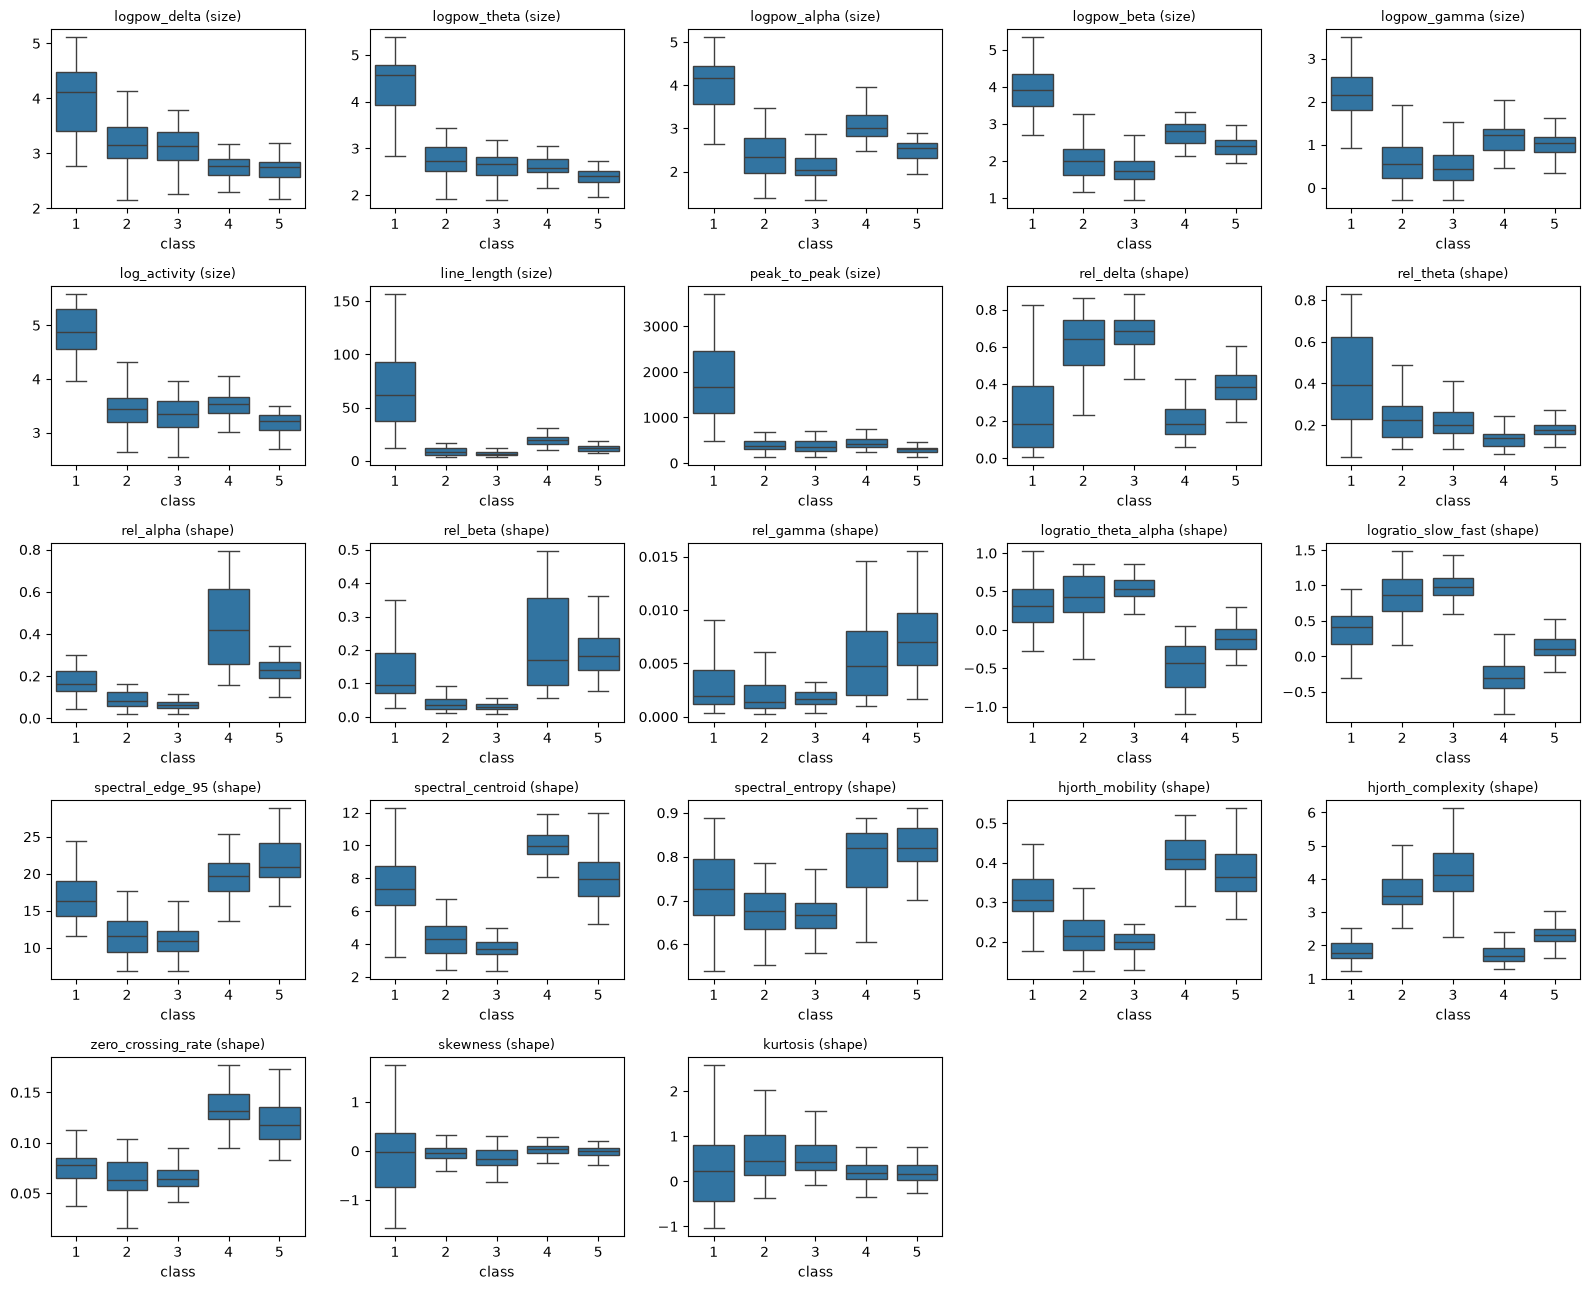

In [3]:
fig, axes = plt.subplots(5, 5, figsize=(16, 13))
for ax, feature in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=dev, x="y", y=feature, ax=ax, showfliers=False)
    ax.set_title(feature + (" (size)" if feature in SIZE_FEATURES else " (shape)"), fontsize=9)
    ax.set_xlabel("class")
    ax.set_ylabel("")
for ax in axes.ravel()[len(FEATURES):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGURES / "11_features_by_class.png", dpi=150)
plt.show()

# Core features per segment

23 features per reconstructed segment (about 4,094 samples), computed from each segment alone. 8 describe size, 15 describe shape. Dev table: 400 segments (80 per class). Hold-out features are saved separately and not inspected.

## Observations (boxplots by class, dev only)
- Seizure (class 1) is far higher than the other classes on every size feature. On shape features it overlaps the others, except for a high theta share.
- Classes 2 and 3 are the slowest signals (high relative delta, low centroid, high complexity) and are almost indistinguishable from each other.
- Classes 4 and 5 (scalp) are the fastest on shape features. Class 4 (eyes closed) has much more alpha than class 5.
- Many features move together (speed: centroid, mobility, zero-crossing rate, spectral edge; size: power bands, activity, line length, peak-to-peak), so there are far fewer than 23 independent ideas.
- Skewness, kurtosis, relative gamma and spectral entropy show little separation.

## Caveats
- Shape features separate scalp from depth recordings, which may confound seizure vs rest.
- One feature at a time: combinations are not tested. Twin segments are counted separately.